Kallumadi, S. & Grer, F. (2018). Drug Reviews (Druglib.com) [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C55G6J.

In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.linear_model import LogisticRegression
from datasets import Dataset
from transformers import AutoTokenizer
from sklearn.utils.class_weight import compute_class_weight
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
from torch import tensor
from torch.nn import CrossEntropyLoss

#visualization
import matplotlib.pyplot as plt
import seaborn as sns

df_sentiment = pd.read_csv("dataset/drugLibTrain_raw.tsv", delimiter="\t")
df_test = pd.read_csv("dataset/drugLibTest_raw.tsv", delimiter="\t")
df_sentiment.head(5)

,Unnamed: 0,urlDrugName,rating,effectiveness,sideEffects,condition,benefitsReview,sideEffectsReview,commentsReview
0,2202,enalapril,4,Highly Effective,Mild Side Effects,management of congestive heart failure,slowed the progression of left ventricular dys...,"cough, hypotension , proteinuria, impotence , ...","monitor blood pressure , weight and asses for ..."
1,3117,ortho-tri-cyclen,1,Highly Effective,Severe Side Effects,birth prevention,Although this type of birth control has more c...,"Heavy Cycle, Cramps, Hot Flashes, Fatigue, Lon...","I Hate This Birth Control, I Would Not Suggest..."
2,1146,ponstel,10,Highly Effective,No Side Effects,menstrual cramps,I was used to having cramps so badly that they...,Heavier bleeding and clotting than normal.,I took 2 pills at the onset of my menstrual cr...
3,3947,prilosec,3,Marginally Effective,Mild Side Effects,acid reflux,The acid reflux went away for a few months aft...,"Constipation, dry mouth and some mild dizzines...",I was given Prilosec prescription at a dose of...
4,1951,lyrica,2,Marginally Effective,Severe Side Effects,fibromyalgia,I think that the Lyrica was starting to help w...,I felt extremely drugged and dopey. Could not...,See above


C:\Users\USER\AppData\Local\Temp\ipykernel_19816\2247632953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='rating', data=df_sentiment, palette='viridis')


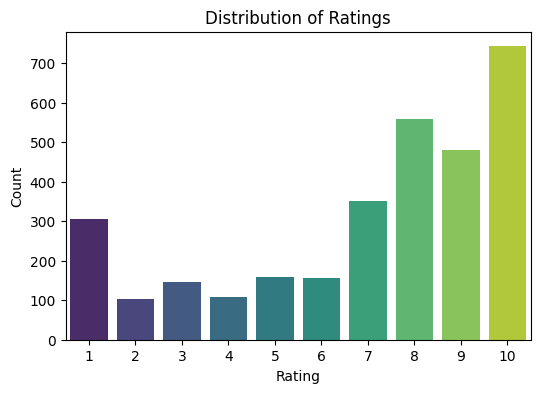

In [2]:
# prompt: plot df_sentiment["rating"] distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=df_sentiment, palette='viridis')
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

# Data Preprocessing

In [3]:
# Binning function as in paper
def bin_rating(r):
    r = int(r)
    if r <= 4: return -1  # Negative
    elif r <= 6: return 0  # Neutral
    else: return 1  # Positive

# Apply to train/test sets
df_sentiment['rating_bin'] = df_sentiment['rating'].apply(bin_rating)
df_test['rating_bin'] = df_test['rating'].apply(bin_rating)


# Combine all text columns as in the paper
for df in [df_sentiment, df_test]:
    df['all_reviews'] = (
        df['benefitsReview'].astype(str) + ' ' +
        df['sideEffectsReview'].astype(str) + ' ' +
        df['commentsReview'].astype(str)
    )

Rating bin:

low = 1-4 (-1)

neutral = 5-6 (0)

high = 7-10 (1)

# Classical NLP Approach

In [4]:
# Prepare data
X_train = df_sentiment['all_reviews']
y_train = df_sentiment['rating_bin']
X_test = df_test['all_reviews']
y_test = df_test['rating_bin']

In [5]:
# CountVectorizer for n-grams (see paper)
vectorizer = CountVectorizer(ngram_range=(1,3), lowercase=True, token_pattern=r'\b\w+\b')
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# Logistic Regression with class weighting
clf = LogisticRegression(class_weight='balanced', max_iter=500, solver='lbfgs')
clf.fit(X_train_vec, y_train)

joblib.dump(clf, "saved_models/clf.joblib")

clf = joblib.load("saved_models/clf.joblib")
y_pred = clf.predict(X_test_vec)


# Evaluation
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

          -1     0.6904    0.5643    0.6210       241
           0     0.4138    0.0960    0.1558       125
           1     0.7667    0.9269    0.8392       670

    accuracy                         0.7423      1036
   macro avg     0.6236    0.5291    0.5387      1036
weighted avg     0.7063    0.7423    0.7060      1036

Confusion matrix:
[[136   4 101]
 [ 25  12  88]
 [ 36  13 621]]
Cohen's Kappa: 0.423116869032772


# BERT-based Approach

In [6]:
# --- Aggressive upsampling to balance classes ---
df_high = df_sentiment[df_sentiment['rating_bin'] == 1]
df_neu  = df_sentiment[df_sentiment['rating_bin'] == 0]
df_low  = df_sentiment[df_sentiment['rating_bin'] == -1]

max_n = max(len(df_high), len(df_neu), len(df_low))
df_high_up = resample(df_high, replace=True, n_samples=max_n, random_state=42)
df_neu_up  = resample(df_neu,  replace=True, n_samples=max_n, random_state=42)
df_low_up  = resample(df_low,  replace=True, n_samples=max_n, random_state=42)

df_balanced = pd.concat([df_high_up, df_neu_up, df_low_up])
print("Balanced train set:", df_balanced['rating_bin'].value_counts())

# --- Prepare texts and labels ---
train_texts = df_balanced['all_reviews'].tolist()
train_labels = df_balanced['rating_bin'].tolist()
test_texts = df_test['all_reviews'].tolist()
test_labels = df_test['rating_bin'].tolist()

le = LabelEncoder()
le.fit([-1, 0, 1])
y_train = le.transform(train_labels)
y_test = le.transform(test_labels)

Balanced train set: rating_bin
 1    2130
 0    2130
-1    2130
Name: count, dtype: int64


In [12]:
# --- Hugging Face Dataset and Tokenization ---
train_ds = Dataset.from_dict({'text': train_texts, 'label': y_train})
test_ds = Dataset.from_dict({'text': test_texts, 'label': y_test})

model_name = "emilyalsentzer/Bio_ClinicalBERT"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize_fn(batch):
    return tokenizer(batch['text'], truncation=True, padding='max_length', max_length=128)

train_ds = train_ds.map(tokenize_fn, batched=True)
test_ds = test_ds.map(tokenize_fn, batched=True)

train_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_ds.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

Map:   0%|          | 0/6390 [00:00<?, ? examples/s]

Map:   0%|          | 0/1036 [00:00<?, ? examples/s]

In [13]:
import torch
# ---Optional: Compute class weights (not strictly needed after perfect balance) ---
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float)

In [15]:
# --- Custom Trainer with class weights (still helps for noisy minority class) ---
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=3)

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = CrossEntropyLoss(weight=class_weights_tensor.to(logits.device))
        loss = loss_fct(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="saved_models/BERT",
    do_eval = True,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    fp16=True,
    logging_steps=100,
    save_strategy="epoch",
    report_to="none",
    eval_strategy="epoch",          # Must evaluate at the same frequency as saving         
    save_total_limit=2,             # (Optional) Prevents disk space exhaustion by limiting saved checkpoints
    load_best_model_at_end=True,    # Automatically loads the best weights after training concludes
    metric_for_best_model="eval_loss", # The metric used to determine the "best" model
    greater_is_better=False         # False for loss (lower is better), True if using F1/Accuracy
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=test_ds,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=10)],
)

trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: emilyalsentzer/Bio_ClinicalBERT
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the chec

Epoch,Training Loss,Validation Loss
1,0.332421,1.141129
2,0.081471,1.819220
3,0.023006,1.917541
4,0.006019,2.102211
5,0.000106,2.106013


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=3995, training_loss=0.14885972168981954, metrics={'train_runtime': 227.6888, 'train_samples_per_second': 140.323, 'train_steps_per_second': 17.546, 'total_flos': 2101618424102400.0, 'train_loss': 0.14885972168981954, 'epoch': 5.0})

In [16]:
# --- Evaluate ---
pred = trainer.predict(test_ds)
y_pred = pred.predictions.argmax(axis=1)

print("Classification report:")
print(classification_report(y_test, y_pred, digits=4, target_names=['Low', 'Neutral', 'High']))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

         Low     0.7090    0.5560    0.6233       241
     Neutral     0.1921    0.2320    0.2101       125
        High     0.7945    0.8254    0.8097       670

    accuracy                         0.6911      1036
   macro avg     0.5652    0.5378    0.5477      1036
weighted avg     0.7019    0.6911    0.6940      1036

Confusion matrix:
[[134  40  67]
 [ 20  29  76]
 [ 35  82 553]]
Cohen's Kappa: 0.3889617953670801


In [17]:
# Copy from logistic regression to ease comparison
print("Classification report:")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print("Cohen's Kappa:", cohen_kappa_score(y_test, y_pred))


Classification report:
              precision    recall  f1-score   support

           0     0.7090    0.5560    0.6233       241
           1     0.1921    0.2320    0.2101       125
           2     0.7945    0.8254    0.8097       670

    accuracy                         0.6911      1036
   macro avg     0.5652    0.5378    0.5477      1036
weighted avg     0.7019    0.6911    0.6940      1036

Confusion matrix:
[[134  40  67]
 [ 20  29  76]
 [ 35  82 553]]
Cohen's Kappa: 0.3889617953670801
